<div style="background-color: lightblue; color: black; border: 2px solid black; 
padding: 15px 25px; border-radius: 8px; margin: 10px 0px;">

  <h2 style="color: black; margin: 0px 0px 10px 0px;">
   Exploration of soil moisture for cells in different HC classes
  </h2>

  <hr style="border: 1px solid black; margin: 10px 0px;">

  <p><strong>Each grid cell in the UK is classified according to its hydraulic conductivity.</strong></p>
   <ul>      
        <li> **Low HC**: very impermeable soils (e.g., clay) </li>
        <li> **Medium HC**: moderately permeable soils (e.g., loam) </li>
        <li> **High HC**: very permeable soils (e.g., sand/gravel) </li>
        </ul>

  <p><strong>Why am I doing this?:</strong></p>
  <ul>
    <li> In AnalyseResults.ipynb compare the antecedent conditions of events happening on clay vs. sandy soils </li>
    <li> Want to know whether those differences are to do with something about the events themselves or just to do with the antecedent conditions on those soils </li>
  </ul>    
    
    
  <p><strong>This script tests:</strong></p>
  <ul>
<!--     <li>The number of events per catchment, per ensemble member with an unphysical value</li>
    <li>The number of pixels affected per event</li> -->
  </ul>

</div>

In [2]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import iris
import iris.quickplot as qplt
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap
import re
from tqdm import tqdm
import glob
import matplotlib.gridspec as gridspec
import pickle
import cartopy.crs as ccrs
import iris.plot as iplt
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap, BoundaryNorm
from affine import Affine
from rasterstats import zonal_stats
import rioxarray


ENSEMBLE_MEMBERS = ['01', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '15']

SOIL_DIR = "/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/soil_texture/"
CATCHMENT_DIR = "/scratch/hydro4/users/kv25483/FutureFlood/Data/CatchmentShapefiles/"
catchments = gpd.read_file(CATCHMENT_DIR + "hyd_areas_GB_with_subcatchments.shp")

HA_NUM = 2

from run_HC_conversion import aggregate_to_5km, convert_to_netcdf, filter_closer_to_catchment

In [4]:
regions_shp = "/scratch/hydro5/users/la17355/FUTURE-FLOOD/Results/Pluvial/v4/#ss/plots/most_exposed_events_visualisation/by_region/ukcp18-uk-land-region-hires.shp"
regions_df = gpd.read_file(regions_shp)

### Join together the Hydraulic Conductivity data for each catchment - one file for whole country

In [5]:
ha_nums = catchments['HA_NUM'].unique()

# Load first cube to get the shape/metadata as template
first = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_nums[0]}.nc")[0]
national_data = np.full(first.shape, np.nan, dtype=np.float32)

for ha_num in tqdm(ha_nums):
    hk_in = iris.load(f"../../Data/HydraulicConductivity/5km_{ha_num}.nc")[0]
    data = hk_in.data  # numpy array or masked array
    
    # Handle masked arrays
    if np.ma.is_masked(data):
        valid = ~data.mask
    else:
        valid = ~np.isnan(data)
    
    # Only fill where this catchment has data and national is still empty
    national_data[valid] = data[valid]

# Put back into a cube using the first cube as template
national_cube = first.copy(data=national_data)
national_cube.rename("hydraulic_conductivity")

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 114/114 [00:06<00:00, 17.63it/s]


### Plot spatially
Plot raw values with log scaling (NB: Raw values here means the mean HC value across a 5km grid cell, based on values at 30m)

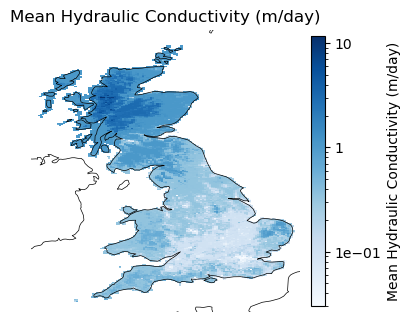

In [6]:
fig = plt.figure(figsize=(4, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())

norm = colors.LogNorm(vmin=np.nanmin(national_cube.data), vmax=np.nanmax(national_cube.data))

mesh = iplt.pcolormesh(national_cube, axes=ax, cmap='Blues', norm=norm)

# Match the styling from the geopandas plot
ax.coastlines(resolution='50m', linewidth=0.5, color='black')
ax.set_title('Mean Hydraulic Conductivity (m/day)')
ax.set_axis_off()

cbar = fig.colorbar(mesh, ax=ax, orientation='vertical',
                     fraction=0.046, pad=0.04)

from matplotlib.ticker import LogFormatter

cbar.formatter = LogFormatter()
cbar.update_ticks()

cbar.set_label('Mean Hydraulic Conductivity (m/day)')

plt.tight_layout()
plt.show()

Same but without the log scaling (so variation among the lower numbers is harder to see)

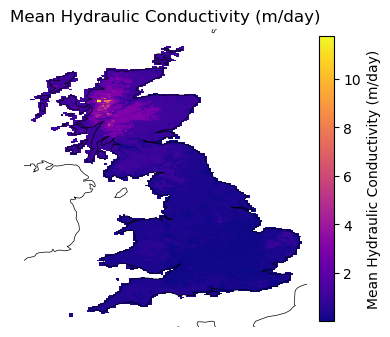

In [7]:
fig = plt.figure(figsize=(4, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())

# Plot the raw cube data with the same colormap as the zonal stats plot
mesh = qplt.pcolormesh(national_cube, axes=ax, cmap='plasma', colorbar=False)

# Match the styling from the geopandas plot
ax.coastlines(resolution='50m', linewidth=0.5, color='black')
ax.set_title('Mean Hydraulic Conductivity (m/day)')
ax.set_axis_off()

# qplt.pcolormesh auto-generates a colorbar with units from the cube,
# but if you want a custom label matching the regions plot exactly:
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical',fraction=0.046, pad=0.04)

cbar.set_label('Mean Hydraulic Conductivity (m/day)')


### Convert into 3 classes (based on equal numbers in each)

In [ ]:
# # Get data
# hk_vals = national_cube.data
# hk_vals_flat = hk_vals.flatten()
# # Convert masked values to np.nan
# if np.ma.is_masked(hk_vals):
#     hk_vals = hk_vals.filled(np.nan)
# # Define class boundaries
# q1, q2 = np.nanquantile(hk_vals, [1/3, 2/3])
# # Convert data to classes
# classified = np.digitize(hk_vals, bins=[q1, q2]).astype(float)
# classified[np.isnan(hk_vals)] = np.nan
# print(q1,q2)

In [ ]:
# # Assign back to cube
# hc_class_cube = national_cube.copy()
# hc_class_cube.data = classified

# fig = plt.figure(figsize=(4, 5))
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())

# # Discrete colormap with 3 classes
# class_labels = ['Low', 'Medium', 'High']  # adjust to your actual classes
# colors = ['gold', 'indigo', 'red']  # 3 viridis-like colors
# cmap = ListedColormap(colors)

# # Boundaries between the 3 classes — assumes class values are 0, 1, 2
# bounds = [-0.5, 0.5, 1.5, 2.5]
# norm = BoundaryNorm(bounds, cmap.N)

# mesh = iplt.pcolormesh(hc_class_cube, axes=ax, cmap=cmap, norm=norm)

# ax.coastlines(resolution='50m', linewidth=0.5, color='black')
# ax.set_title('Hydraulic Conductivity Class')
# ax.set_axis_off()

# # Colorbar on the side, sized to match the axes, with class tick labels
# cbar = fig.colorbar(mesh, ax=ax, orientation='vertical',
#                      fraction=0.046, pad=0.04, ticks=[0, 1, 2])
# cbar.ax.set_yticklabels(class_labels)
# cbar.set_label('HC Class')

# plt.tight_layout()
# plt.show()


### Convert into 3 classes (based on HC values - GA version)

In [ ]:
# # Get data
# hk_vals = national_cube.data
# # hk_vals_flat = hk_vals.flatten()
# # Convert masked values to np.nan
# if np.ma.is_masked(hk_vals):
#     hk_vals = hk_vals.filled(np.nan)
# # Define class boundaries
# q1 = 0.5
# q2 = 3
# # Convert data to classes
# classified = np.digitize(hk_vals, bins=[q1, q2]).astype(float)
# classified[np.isnan(hk_vals)] = np.nan

# # np.unique(classified,return_counts=True)
# # (6300 +  3823 + 116)# 10239
# # 61.5, 37.3,  1.1

In [ ]:
# # Assign back to cube
# hc_class_cube = national_cube.copy()
# hc_class_cube.data = classified

# fig = plt.figure(figsize=(4, 5))
# ax = plt.axes(projection=ccrs.PlateCarree())
# ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())

# # Discrete colormap with 3 classes
# class_labels = ['D', 'C',  'B']  # adjust to your actual classes
# colors = ['indigo', 'gold',  'red']  # 3 viridis-like colors
# cmap = ListedColormap(colors)

# # Boundaries between the 3 classes — assumes class values are 0, 1, 2
# mesh = iplt.pcolormesh(hc_class_cube, axes=ax, cmap=cmap)

# ax.coastlines(resolution='50m', linewidth=0.5, color='black')
# ax.set_title('Hydraulic Conductivity Class')
# ax.set_axis_off()

# # Colorbar on the side, sized to match the axes, with class tick labels
# cbar = fig.colorbar(mesh, ax=ax, orientation='vertical',
#                      fraction=0.046, pad=0.04, ticks=[0.3, 1, 1.5])
# cbar.ax.set_yticklabels(class_labels)
# cbar.set_label('HC Class')

# plt.tight_layout()
# plt.show()


### Convert into 3 classes (based on HC values - corrected version)

In [ ]:
# Get data
hk_vals = national_cube.data
# hk_vals_flat = hk_vals.flatten()
# Convert masked values to np.nan
if np.ma.is_masked(hk_vals):
    hk_vals = hk_vals.filled(np.nan)
# Define class boundaries
q1 = 0.15 
q2 = 1.1
q3 = 3 

# Convert data to classes (flip the order)
classified = 3 - np.digitize(hk_vals, bins=[q1, q2, q3])
classified = classified.astype(float)
classified[np.isnan(hk_vals)] = np.nan

# np.unique(classified,return_counts=True)
# (1872 +  7234 + 1017+   116)# 10239
# 18.3, 70.7, 9.9, 1.1

In [ ]:
# Assign back to cube
hc_class_cube = national_cube.copy()
hc_class_cube.data = classified

fig = plt.figure(figsize=(4, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-8, 2, 49.5, 60], crs=ccrs.PlateCarree())

# Discrete colormap with 3 classes
class_labels = ['A', 'B', 'C', 'D']  # adjust to your actual classes
colors = [ 'red', 'gold', 'indigo','darkgreen', ]  # 3 viridis-like colors
cmap = ListedColormap(colors)

mesh = iplt.pcolormesh(hc_class_cube, axes=ax, cmap=cmap)

ax.coastlines(resolution='50m', linewidth=0.5, color='black')
ax.set_title('Hydraulic Conductivity Class')
ax.set_axis_off()

# Colorbar on the side, sized to match the axes, with class tick labels
cbar = fig.colorbar(mesh, ax=ax, orientation='vertical',
                     fraction=0.046, pad=0.04, ticks=[0.4, 1.1, 1.9, 2.5])
cbar.ax.set_yticklabels(class_labels)
cbar.set_label('HC Class')

### Find the mean HC in each region

In [ ]:
# Extract data and coordinates from the cube
hc_data = national_cube.data  # shape (244, 180)

y_coord = national_cube.coord('projection_y_coordinate').points
x_coord = national_cube.coord('projection_x_coordinate').points

# Resolution (assumes regular grid spacing, true for UKCP18/OSGB grids)
res_x = x_coord[1] - x_coord[0]
res_y = y_coord[1] - y_coord[0]

# Iris coords are usually ascending in y; rasterio/affine expects the
# transform's origin at the top-left, with a *negative* y-resolution.
# So if y_coord is ascending, flip the data vertically to match.
if y_coord[1] > y_coord[0]:
    hc_data = np.flipud(hc_data)
    top_left_y = y_coord[-1] + res_y / 2
else:
    top_left_y = y_coord[0] + res_y / 2

top_left_x = x_coord[0] - res_x / 2

transform = Affine(res_x, 0, top_left_x,
                    0, -abs(res_y), top_left_y)

if regions_df.crs is None:
    regions_df = regions_df.set_crs(epsg=27700)  # set if you know it's already BNG
else:
    regions_df = regions_df.to_crs(epsg=27700)
    
stats = zonal_stats(regions_df,hc_data,affine=transform,stat=['mean'],nodata=np.nan,geojson_out=False)

regions_df['mean_HC'] = [s['mean'] for s in stats]    

fig, ax = plt.subplots(figsize=(4, 5))

regions_df.plot( column='mean_HC', cmap='Blues', legend=True, edgecolor='black', linewidth=0.5, ax=ax, 
                legend_kwds={'label': 'Mean Hydraulic Conductivity (m/day)'})

ax.set_title('Mean Hydraulic Conductivity by Geo-region')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Compare to topography

In [ ]:
national_5km_dem = '/scratch/hydro4/users/la17355/FUTURE-FLOOD/Data/Model_builds/Pluvial/v4/dem_5km_national_mosaic.tif'
mosaic = rioxarray.open_rasterio(national_5km_dem,masked=True).squeeze(drop=True)
print(mosaic.shape, mosaic.rio.crs, mosaic.rio.resolution())

In [ ]:
dem_flat = mosaic.data.flatten()
hk_vals_flat = hk_vals.flatten()

In [ ]:
mask = hk_vals_flat < 4

plt.scatter(hk_vals_flat[mask], dem_flat[mask])
plt.xlabel('Hydraulic conductivity')
plt.ylabel('Elevation (m)')

In [ ]:
plt.scatter(hk_vals_flat, dem_flat)
plt.xlabel('Hydraulic conducitivity')
plt.ylabel('Elevation (m)');

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot seasonal cycle in soil moisture (across all EMs and all years [1980-2080]) </h3>
</div>

---

all_years_data is: a dictionary of lists of NumPy array

```
{
  "low (0–0.3)":  [array(360,), array(360,), ...],
  "mid (0.3–0.7)": [...],
  "high (0.7–1.0)": [...]
}
```

Keys are: HK classes
Each key maps to a list where each entry corresponds to: one year & one ensemble member
Each element in the list = 1D array containing -> daily mean soil moisture for that HK class over one year

---

In [ ]:
bin_labels = ['A', 'B', 'C', 'D']

In [ ]:
pickle_path = '../../Data/SoilInfo/all_years_data.pickle'
if os.path.exists(pickle_path):
    print("Reading from file")
    with open(pickle_path, 'rb') as handle:
        all_years_data = pickle.load(handle)

else:        
    # Create empty dictionary to store results 
    all_years_data = {label: [] for label in bin_labels}

    # Loop over ensembles and years
    for ens in ENSEMBLE_MEMBERS:
        # Load soil moisture data
        sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
        for year in tqdm(range(1980, 2080)):
            # Get the soil moisture data
            try:
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
            except IndexError:
                continue

            sm_yr = iris.load(sm_file)[0]
            # Convert masked → NaN
            sm_arr = sm_yr.data.filled(np.nan) if np.ma.is_masked(sm_yr.data) else sm_yr.data

            # Extract data by HK class
            for i, label in enumerate(bin_labels):
                # Build a spatial mask for each HK class
                mask = classified == (i )
                # Compute daily mean soil moisture for that class
                all_years_data[label].append({"ensemble": ens,"year": year, "data": np.nanmean(sm_arr[:, mask], axis=1) })
                
                
    with open(pickle_path, 'wb') as handle:
        pickle.dump(all_years_data, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
import rasterio.features
from shapely.ops import unary_union

# ── DEFINE REGIONS ──────────────────────────────────────
region_names = np.unique(regions_df['geo_region'])
regions = {name: regions_df[regions_df['geo_region'] == name] for name in region_names}

# ── BUILD REGION MASKS ONCE (needs a reference grid) ────
# grab one soil moisture file just to get the grid shape/coords
ref_file = glob.glob(f"/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ENSEMBLE_MEMBERS[0]}/r001i1p*****_19801201-19811130_mrso.nc")
ref_cube = iris.load(ref_file)[0]

y_coords = ref_cube.coord('projection_y_coordinate').points
x_coords = ref_cube.coord('projection_x_coordinate').points
res_y = abs(y_coords[1] - y_coords[0])
res_x = abs(x_coords[1] - x_coords[0])

if y_coords[0] < y_coords[-1]:
    # row 0 = south (ascending y) → origin='lower' convention
    transform = Affine(res_x, 0, x_coords.min() - res_x/2,
                        0, res_y, y_coords.min() - res_y/2)
else:
    # row 0 = north (descending y) → origin='upper' convention  
    transform = Affine(res_x, 0, x_coords.min() - res_x/2,
                        0, -res_y, y_coords.max() + res_y/2)

region_masks = {}
for name, gdf in regions.items():
    geom = unary_union(gdf.geometry)
    region_masks[name] = ~rasterio.features.geometry_mask(
        [geom],
        out_shape=(len(y_coords), len(x_coords)),
        transform=transform,
        invert=False )

# ── MAIN LOOP ────────────────────────────────────────────
pickle_path = '../../Data/SoilInfo/all_years_data_by_region.pickle'

if os.path.exists(pickle_path):
    print("Reading from file")
    with open(pickle_path, 'rb') as handle:
        all_years_data_regional = pickle.load(handle)
else:
    # nested dict: region → bin_label → list of results
    all_years_data_regional = {region_name: {label: [] for label in bin_labels}
        for region_name in region_names}

    for ens in ENSEMBLE_MEMBERS:
        print(ens)
        sm_dir = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
        for year in tqdm(range(1980, 2080), mininterval=5):
            try:
                sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
            except IndexError:
                continue

            sm_yr = iris.load(sm_file)[0]
            sm_arr = sm_yr.data.filled(np.nan) if np.ma.is_masked(sm_yr.data) else sm_yr.data

            for region_name, region_mask in region_masks.items():
                for i, label in enumerate(bin_labels):
                    hk_mask = classified == i
                    combined_mask = hk_mask & region_mask

                    all_years_data_regional[region_name][label].append({"ensemble": ens, "year": year,
                        "data": np.nanmean(sm_arr[:, combined_mask], axis=1) })

    with open(pickle_path, 'wb') as handle:
        pickle.dump(all_years_data_regional, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [ ]:
# valid_mask = ~np.isnan(classified)
# print(f"Total valid (non-NaN) cells in classified: {valid_mask.sum()} / {classified.size}")

# # overlay against region masks to see which regions have ANY valid HK data
# for name, region_mask in region_masks.items():
#     n_valid = (region_mask & valid_mask).sum()
#     n_total = region_mask.sum()
#     print(f"{name}: {n_valid}/{n_total} cells have valid HK classification")

In [ ]:
days = np.arange(360)
color_map = {'A': 'red','B': 'gold','C': 'indigo','D': 'green'}
color_map.items()

for region_name in region_names:
    fig, ax = plt.subplots(figsize=(14, 5))

    for label in color_map.keys():
        stack = np.stack( [entry["data"] for entry in all_years_data_regional[region_name][label]], axis=0)
        clim_mean = np.nanmean(stack, axis=0)   # (360,)
        clim_std  = np.nanstd(stack,  axis=0)   # (360,)

        ax.plot(days, clim_mean, label=label, color=color_map[label])
        ax.fill_between(days,clim_mean - clim_std, clim_mean + clim_std,alpha=0.15, color=color_map[label])

    ax.set_xlabel("Day of year (Dec–Nov)")
    ax.set_ylabel("Soil moisture (kg/m²)")
    ax.set_title(f"Climatological daily SM by HC class, {region_name}, 1980–2020")
    ax.legend(title="HC class (m/day)")
    plt.tight_layout()
    plt.show()

In [ ]:
# Plot climatological mean +/- std across years
fig, ax = plt.subplots(figsize=(14, 5))
days = np.arange(360)

for label in color_map.keys():
    stack = np.stack( [entry["data"] for entry in all_years_data[label]],axis=0)
    clim_mean = np.nanmean(stack, axis=0)             # (360,)
    clim_std  = np.nanstd(stack,  axis=0)             # (360,)

    ax.plot(days, clim_mean, label=label, color=color_map[label])
    ax.fill_between(days,
                    clim_mean - clim_std,
                    clim_mean + clim_std, 
                    alpha=0.15, color=color_map[label])

ax.set_xlabel("Day of year (Dec–Nov)")
ax.set_ylabel("Soil moisture (kg/m²)")
ax.set_title("Climatological daily SM by HC class, 1980–2020")
ax.legend(title="HC class (m/day)")
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot  </h3>
</div>

In [ ]:
bin_labels = ['A', 'B', 'C', 'D']

out_path = '../../Data/SoilInfo/yearly_sm_per_bin_new.csv'

if os.path.isfile(out_path):
    print("Reading from file")
    df = pd.read_csv(out_path)
else:
    print("creating")
    ens = '01'
    sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'

    results = []

    for year in tqdm(range(1980, 2081)):
        try:
            sm_file = glob.glob(
                f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
        except IndexError:
            continue

        sm_arr = iris.load(sm_file)[0].data
        if np.ma.is_masked(sm_arr):
            sm_arr = sm_arr.filled(np.nan)

        for i, label in enumerate(bin_labels):
            mask = classified == i 
            results.append({ "year": year, "hk_bin": label,   "mean_sm": np.nanmean(sm_arr[:, mask]),  
                "std_sm":  np.nanstd(sm_arr[:, mask]),})

    df = pd.DataFrame(results)
    df.to_csv(out_path)

In [ ]:
# slopes = []

# for ens in ['01', '04']:
#     df_ens = df[df["ensemble"] == ens]
    
#     for label in bin_labels:
#         s = df_ens[df_ens["hk_bin"] == label]
#         s_year = s.groupby("year")["mean_sm"].mean().reset_index()
        
#         x = s_year["year"].values
#         y = s_year["mean_sm"].values
        
#         if len(x) > 1:
#             m, _ = np.polyfit(x, y, 1)
            
#             slopes.append({"ensemble": ens,"bin": label,"slope": m})

In [ ]:
seasons = { "DJF (Dec-Feb)": slice(0,   90),
        "MAM (Mar-May)": slice(90,  180),
        "JJA (Jun-Aug)": slice(180, 270),
        "SON (Sep-Nov)": slice(270, 360),}

out_path =  '../../Data/SoilInfo/yearly_sm_seasonal_per_bin_new.csv'

if not os.path.isfile(out_path):
    print("Reading from file")
    df_seasonal = pd.read_csv(out_path)
else:
    print("Producing output")
    # Assuming Dec-Nov year: days 0-89=Dec-Feb, 90-179=Mar-May, etc.
    results = []

    for year in tqdm(range(1980, 2081)):
        ens= '01'
        sm_dir  = f'/scratch/hydro4/shared_data/climate_projections/UKCP18/UKCP_local/Soil_moisture/5km_regridded/Ens_{ens}/'
        try:
            sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
        except IndexError:
            continue

        sm_arr = iris.load(sm_file)[0].data
        if np.ma.is_masked(sm_arr):
            sm_arr = sm_arr.filled(np.nan)

        for i, label in enumerate(bin_labels):
            mask = classified == i
            for season, sl in seasons.items():
                results.append({ "year": year, "hk_bin": label, "season": season, "mean_sm": np.nanmean(sm_arr[sl, mask])})

    df_seasonal = pd.DataFrame(results)
    df_seasonal.to_csv(out_path, index=False)

In [ ]:
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, height_ratios=[1.2, 1, 1])

# ── TOP: FULL YEAR (spans both columns) ─────────────────────────────
ax_full = fig.add_subplot(gs[0, :])

for label in color_map.keys():    
    s = df[df["hk_bin"] == label]
    s_year = s.groupby("year")["mean_sm"].mean().reset_index()
    ax_full.plot(s_year["year"], s_year["mean_sm"], color=color_map[label])
    
    # --- Fit trendline ---
    # (better to aggregate by year in case of duplicates)
    s_year = s.groupby("year")["mean_sm"].mean().reset_index()
    
    x = s_year["year"].values
    y = s_year["mean_sm"].values
    
    if len(x) > 1:  # avoid crashes
        m, b = np.polyfit(x, y, 1)
        label_with_slope = f"{label} (slope={m:.3f})"
        ax_full.plot(x, m*x + b, color=color_map[label], linestyle="--", linewidth=2, label =label)

ax_full.set_title("Full year")
ax_full.set_xlabel("Year")
ax_full.set_ylabel("Mean SM (kg/m²)")

# ── BOTTOM: SEASONAL 2x2 ────────────────────────────────────────────
axes = [fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
    fig.add_subplot(gs[2, 1]),]

for ax, season in zip(axes, seasons.keys()):
    sub = df_seasonal[df_seasonal["season"] == season]
    
    for label in color_map.keys():    
        s = sub[sub["hk_bin"] == label]
        
        s_seasonal = s.groupby("year")["mean_sm"].mean().reset_index()
        x = s_seasonal["year"].values
        y = s_seasonal["mean_sm"].values
        if len(x) > 1:  # avoid crashes
            m, b = np.polyfit(x, y, 1)
            label_with_slope = f"{label} (slope={m:.3f})"
            ax.plot(x, m*x + b, color=color_map[label],
                    linestyle="--", linewidth=2)
            
        ax.plot(s["year"], s["mean_sm"], label=label, color=color_map[label])
    
    ax.set_title(season)
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean SM (kg/m²)")

# legend only once
ax_full.legend(title="HC class")

plt.suptitle("Seasonal SM trends by HC class, 1980–2080", fontsize=13)
plt.tight_layout()
plt.show()

<div style="background-color: lightblue; color: black;  border: 2px solid black; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;"><h3 style="color: black; margin: 0px;"> Plot seasonal cycle in soil moisture (across all EMs and all years [1980-2080]) </h3>
</div>

In [ ]:
periods = {"1980–2020": range(1980, 2020), "2020–2050": range(2020, 2050), "2050–2080": range(2050, 2080),}

# Accumulate daily means per bin per period
period_data = {period: {label: [] for label in bin_labels}
    for period in periods}

for period, years in periods.items():
    for year in tqdm(years, desc=period):
        try:
            sm_file = glob.glob(f"{sm_dir}/r001i1p*****_{year-1}1201-{year}1130_mrso.nc")[0]
        except IndexError:
            continue

        sm_arr = iris.load(sm_file)[0].data
        if np.ma.is_masked(sm_arr):
            sm_arr = sm_arr.filled(np.nan)

        for i, label in enumerate(bin_labels):
            mask = classified == i 
            period_data[period][label].append(
                np.nanmean(sm_arr[:, mask], axis=1))

In [ ]:
import numpy as np
# Plot seasonal cycle per bin, coloured by period
period_colors = ["blue", "purple", "orange"]
days = np.arange(360)

fig, axes = plt.subplots(1, len(bin_labels), figsize=(16, 5), sharey=True)

for ax, label in zip(axes, bin_labels):
    for (period, p_color) in zip(periods.keys(), period_colors):
        stack = np.stack(period_data[period][label], axis=0)  # (n_years, 360)
        clim  = np.nanmean(stack, axis=0)                     # (360,)
        ax.plot(days, clim, label=period, color=p_color)

    ax.set_title(label)
    ax.set_xlabel("Day of year (Dec–Nov)")

axes[0].set_ylabel("Mean SM (kg/m²)")
axes[0].legend(title="Period")
plt.suptitle("Shift in seasonal SM cycle by HC class", fontsize=13)
plt.tight_layout()
plt.show()